In [6]:
import os
import cv2
import numpy as np
from mayavi import mlab
# print(mlab.__file__)

import matplotlib.pyplot as plt
from scipy.interpolate import LinearNDInterpolator
import sys


In [7]:
class HiddenPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

def surface_Diff(surface1, surface2):
    squared_diff = (surface1 - surface2)
    
    return squared_diff

def surface_RMSE(surface1, surface2):
    squared_diff = (surface1 - surface2) ** 2
    rmse = np.sqrt(np.mean(squared_diff))
    
    return squared_diff

import warnings
warnings.filterwarnings("ignore")

def mask_circle(image):
    height, width = image.shape[:2]
    mask = np.zeros((height, width), dtype=np.uint8)
    center = (width // 2, height // 2)
    radius = width // 2
    mask = cv2.circle(mask, center, radius, 1, thickness=-1)
    image = cv2.bitwise_and(image, image, mask=mask)
    
    # print(image.shape, np.min(image), np.max(image), image.dtype, image[1,1])
    
    return image


/Users/fan/Projects/Digital Eye/models/Depth-Retina github/examples
	GT: 5781.0 7715.0 	PRED: 5866.1 7784.8 	D.GT: 1934.0 	D.PRED: 1918.7 	D.MAX DIFF PIX: -15.3


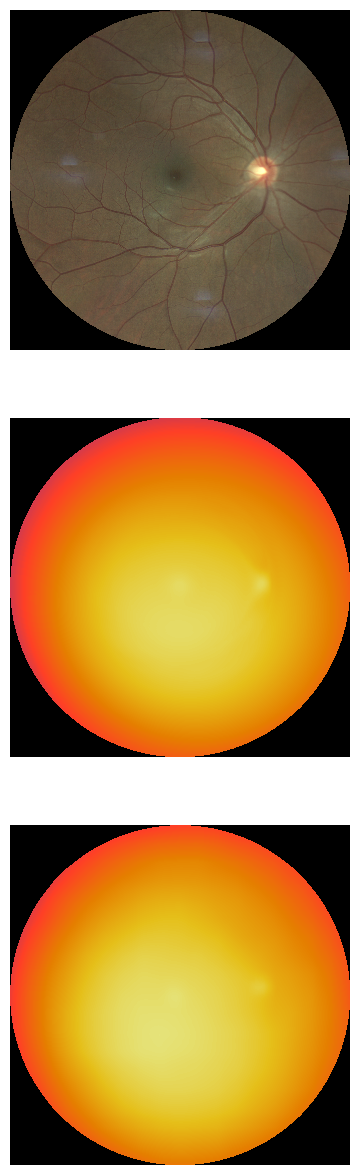

qt.qpa.window: <QNSWindow: 0x7f866ee191b0; contentView=<QNSView: 0x7f866ee18db0; QCocoaWindow(0x600000a34bb0, window=QWidgetWindow(0x6000017c3c60, name="QMainWindowClassWindow"))>> has active key-value observers (KVO)! These will stop working now that the window is recreated, and will result in exceptions when the observers are removed. Break in QCocoaWindow::recreateWindowIfNeeded to debug.
qt.qpa.window: <QNSWindow: 0x7f8697745a70; contentView=<QNSView: 0x7f8697745670; QCocoaWindow(0x600000a3da20, window=QWidgetWindow(0x600005942d60, name="QMainWindowClassWindow"))>> has active key-value observers (KVO)! These will stop working now that the window is recreated, and will result in exceptions when the observers are removed. Break in QCocoaWindow::recreateWindowIfNeeded to debug.


In [25]:
# %pwd
# %cd "/Users/fan/Projects/Digital Eye/models/Depth-Retina github/examples"

sys.path.append(r'../depth_retina')
import run

model_dir = '../depth_retina/checkpoints/'
model_name = 'zoedepth'
pretrained_dir = 'local::' + '/Users/fan/Projects/Digital Eye/models/Depth-Retina github/depth_retina/checkpoints/' #model_dir

samples = [ ['./images/00350_20230304008_OD.png', 'model_0904_100epoch_latest.pt', 'image_zeiss_0_SR', '2170'],
            ['./images/00350_20230408007_OS.png', 'model_0904_100epoch_latest.pt', 'image_zeiss_0_SR', '1833'] ]

depth_rep = ['1278 22 h_px 53 v_px 400 um',
             '1280 22 h_px 53 v_px 400 um',
             '1832 17 h_px 39 v_px 200 um',
             '1833 17 h_px 39 v_px 200 um',
             '2170 19 h_px 45 v_px 200 um',
             '2562 23 h_px 54 v_px 200 um',
             '3830 34 h_px 80 v_px 200 um']

um_per_pix_v = {}
vertical_times = {}
for unit in depth_rep:
    unit_num = unit.split(' ')
    um_per_pix_v[int(unit_num[0])] = float(unit_num[5]) / float(unit_num[3])
    vertical_times[int(unit_num[0])] = float(unit_num[3]) / float(unit_num[1])

def get_result(sample, infer=True, show=False):

    pretrained_resource = pretrained_dir + sample[1]
            
    image = cv2.imread(sample[0], -1)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    Z_gt = cv2.imread(sample[0].replace('.png', '_GT.png'), -1)
    Z_gt = Z_gt[254:1278, 254:1278]
    Z_gt = np.asarray(Z_gt, dtype=np.float32)
    Z_gt = Z_gt - 150

    X_gt = np.linspace(0, Z_gt.shape[0], Z_gt.shape[0])
    Y_gt = np.linspace(0, Z_gt.shape[1], Z_gt.shape[1])
    X_gt, Y_gt = np.meshgrid(X_gt, Y_gt)

    X_gt_xc = X_gt[int(Z_gt.shape[0]/2), :]
    Y_gt_xc = Y_gt[int(Z_gt.shape[0]/2), :]
    Z_gt_xc = Z_gt[int(Z_gt.shape[0]/2), :]
    
    X_gt_yc = X_gt[:, int(Z_gt.shape[0]/2)]
    Y_gt_yc = Y_gt[:, int(Z_gt.shape[0]/2)]
    Z_gt_yc = Z_gt[:, int(Z_gt.shape[0]/2)]
    
    if infer==True:
        with HiddenPrints():
            os.chdir(model_dir)
            model = run.load_model(model_name, pretrained_resource)
            Z_pred = run.infer(model, image)
            os.getcwd()

        Z_pred = Z_pred.numpy() * 45
        Z_pred = Z_pred[0][0]
    else:
        Z_pred = np.ones([1024, 1024]) * 0.5

    X_pred = np.linspace(0, Z_pred.shape[0], Z_pred.shape[0])
    Y_pred = np.linspace(0, Z_pred.shape[1], Z_pred.shape[1])
    X_pred, Y_pred = np.meshgrid(X_pred, Y_pred)
    sx = X_pred.reshape(1, -1)[0].copy()
    sy = Y_pred.reshape(1, -1)[0].copy()
    sz = Z_pred.reshape(1, -1)[0].copy()
    X_pred = np.linspace(0, Z_pred.shape[0], Z_gt.shape[0])
    Y_pred = np.linspace(0, Z_pred.shape[1], Z_gt.shape[1])
    X_pred, Y_pred = np.meshgrid(X_pred, Y_pred)

    interp = LinearNDInterpolator(list(zip(sx, sy)), sz)
            
    Z_pred = interp(X_pred, Y_pred)
    enlarge = 1024.0 / 518.0
    X_pred, Y_pred = X_pred * enlarge, Y_pred * enlarge

    diff_pred = surface_Diff(Z_gt, Z_pred)
    
    image = mask_circle(image)
    Z_gt = mask_circle(Z_gt)
    Z_pred = mask_circle(Z_pred)
    diff_pred = mask_circle(diff_pred) / 1000

    Z_gt_max = round(Z_gt[Z_gt.shape[1]//2, Z_gt.shape[0]//2], 1)
    Z_gt_min = round(np.min(Z_gt[Z_gt>0]), 1)
    Z_pred_max = round(Z_pred[Z_pred.shape[1]//2, Z_pred.shape[0]//2], 1)
    Z_pred_min = round(np.min(Z_pred[Z_pred>0]), 1)
    
    d_gt = round(Z_gt_max - Z_gt_min, 1)
    d_pred = round(Z_pred_max - Z_pred_min, 1)
    d_diff = round(d_pred - d_gt, 1)

    X_pred_xc = X_pred[int(Z_pred.shape[0]/2), :]
    Y_pred_xc = Y_pred[int(Z_pred.shape[0]/2), :]
    Z_pred_xc = Z_pred[int(Z_pred.shape[0]/2), :]
    X_pred_yc = X_pred[:, int(Z_pred.shape[0]/2)]
    Y_pred_yc = Y_pred[:, int(Z_pred.shape[0]/2)]
    Z_pred_yc = Z_pred[:, int(Z_pred.shape[0]/2)]

    print(
          '\tGT:', Z_gt_min, Z_gt_max, 
          '\tPRED:', Z_pred_min, Z_pred_max,
          '\tD.GT:', d_gt,
          '\tD.PRED:', d_pred,
          '\tD.MAX DIFF PIX:', d_diff
         )
    
    v_mag = um_per_pix_v[int(sample[3])] * float(sample[3]) / 1531.0

    if show == True:
        fig, ax = plt.subplots(3, 1, figsize=(10, 15), dpi=100)
        
        ax[0].imshow(image, vmin=0, vmax=255, interpolation='nearest')
        ax[1].imshow(Z_gt, plt.cm.CMRmap, vmin=3600, vmax=8500, interpolation='nearest') #, vmin=0, vmax=205*45
        ax[2].imshow(Z_pred, plt.cm.CMRmap, vmin=3600, vmax=8500, interpolation='nearest') #, vmin=0, vmax=205*45
    
        ax[0].set_aspect(1)
        ax[1].set_aspect(1)
        ax[2].set_aspect(1)
        ax[0].axis('off')
        ax[1].axis('off')
        ax[2].axis('off')
        plt.show()

    v_mag_real = v_mag * vertical_times[int(sample[3])]
    vmin = 800
    vmax = 1300
    vmin_real = vmin / vertical_times[int(sample[3])]
    vmax_real = vmax / vertical_times[int(sample[3])]

    Z_gt[Z_gt==0] = np.nan
    Z_pred[Z_pred==0] = np.nan
    
    # if save==True:
    #     f.write(sample[0] + ',0,X,' + ','.join(map(str, X_gt_yc_0_ori.flatten())) + '\n')
    #     f.write(sample[0] + ',0,Z,' + ','.join(map(str, Z_gt_yc_0_ori.flatten())) + '\n')
        
    #     f.write(sample[0] + ',1,X,' + ','.join(map(str, X_gt_yc_1_ori.flatten())) + '\n')
    #     f.write(sample[0] + ',1,Z,' + ','.join(map(str, Z_gt_yc_1_ori.flatten())) + '\n')

    #     f.write(sample[0] + ',2,X,' + ','.join(map(str, X_gt_yc_2_ori.flatten())) + '\n')
    #     f.write(sample[0] + ',2,Z,' + ','.join(map(str, Z_gt_yc_2_ori.flatten())) + '\n')

    if show == True:
        mlab.figure('GT scan', bgcolor=(0.9, 0.9, 0.9), size=(800, 800))
        mlab.mesh(X_gt, Y_gt, Z_gt/v_mag, resolution=8, colormap='RdYlBu', representation='surface', opacity=0.77, vmin=vmin, vmax=vmax)
        mlab.plot3d(X_gt_xc, Y_gt_xc, Z_gt_xc/v_mag, tube_radius=2, color=(0.07, 0.44, 0.36))
        mlab.plot3d(X_gt_yc, Y_gt_yc, Z_gt_yc/v_mag, tube_radius=2, color=(0.46, 0.09, 0.83))
        
        orientation_axes = mlab.orientation_axes()
        orientation_axes.axes.x_axis_label_text = ''
        orientation_axes.axes.y_axis_label_text = ''
        orientation_axes.axes.z_axis_label_text = ''
    
        mlab.figure('PRED scan', bgcolor=(0.9, 0.9, 0.9), size=(800, 800))
        mlab.mesh(X_pred, Y_pred, Z_pred/v_mag, resolution=8, colormap='RdYlBu', representation='surface', opacity=0.77, vmin=vmin, vmax=vmax)
        mlab.plot3d(X_pred_xc, Y_pred_xc, Z_pred_xc/v_mag, tube_radius=2, color=(0.07, 0.44, 0.36))
        mlab.plot3d(X_pred_yc, Y_pred_yc, Z_pred_yc/v_mag, tube_radius=2, color=(0.46, 0.09, 0.83))
    
    # if save==True:
    #     f.close()

get_result(samples[0], infer=True, show=True)

mlab.show()
